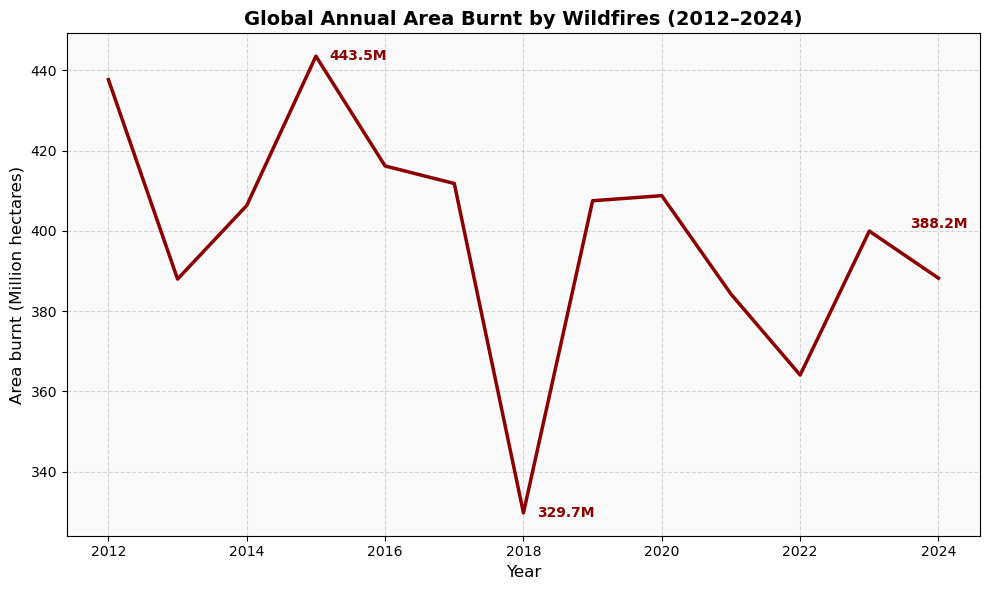

C:\Users\jincy\AppData\Local\Temp\ipykernel_29368\1596685545.py:77: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



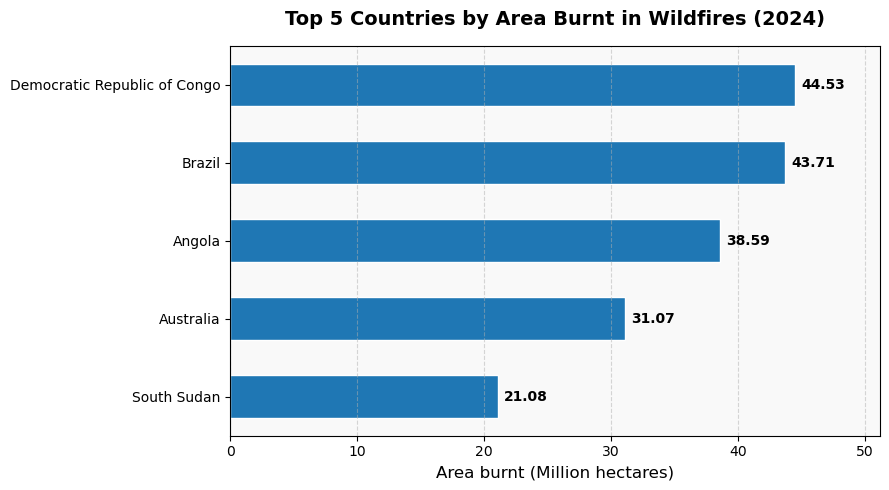

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

# === Load dataset ===
file_path = r"C:\Users\jincy\OneDrive\Desktop\TealProject\Datasets\annual-area-burnt-by-wildfires\annual-area-burnt-by-wildfires.csv"
df = pd.read_csv(file_path)

# === Standardize column names ===
df.rename(columns={
    "Entity": "Entity",
    "Code": "Code",
    "Year": "Year",
    "Annual area burnt by wildfires": "BurntArea"
}, inplace=True)

# === Ensure numeric types ===
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["BurntArea"] = pd.to_numeric(df["BurntArea"], errors="coerce")

# === 🔹 Filter from 2012 to 2024 ===
df = df[(df["Year"] >= 2012) & (df["Year"] <= 2024)]


# === Trend plot for World with clean custom annotations ===
world = df[df["Entity"] == "World"].copy()
world["BurntArea_Mha"] = world["BurntArea"] / 1e6

plt.figure(figsize=(10,6))
plt.plot(world["Year"], world["BurntArea_Mha"], 
         color="darkred", linewidth=2.5)

# Title & labels
plt.title("Global Annual Area Burnt by Wildfires (2012–2024)", fontsize=14, weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Area burnt (Million hectares)", fontsize=12)

# Style
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().set_facecolor("#f9f9f9")

# === Find key points ===
min_idx = world["BurntArea_Mha"].idxmin()
max_idx = world["BurntArea_Mha"].idxmax()
last_idx = world[world["Year"] == 2024].index[0]

year_min, val_min = world.loc[min_idx, ["Year", "BurntArea_Mha"]]
year_max, val_max = world.loc[max_idx, ["Year", "BurntArea_Mha"]]
year_last, val_last = world.loc[last_idx, ["Year", "BurntArea_Mha"]]

# === Add annotations ===
# Highest → immediate right
plt.text(year_max + 0.2, val_max, f"{val_max:.1f}M",
         va="center", ha="left", fontsize=10, weight="bold", color="darkred")

# Lowest → immediate right
plt.text(year_min + 0.2, val_min, f"{val_min:.1f}M",
         va="center", ha="left", fontsize=10, weight="bold", color="darkred")

# 2024 → just above
plt.text(year_last, val_last + (val_last*0.03), f"{val_last:.1f}M",
         va="bottom", ha="center", fontsize=10, weight="bold", color="darkred")

plt.tight_layout()
plt.show()


# === 2. Filter out invalid codes ===
valid_countries = df[df["Code"].notna() & (df["Code"].str.len() == 3)]

# === 3. Latest year data for map ===
latest_year = valid_countries["Year"].max()
latest_data = valid_countries[valid_countries["Year"] == latest_year]

# log transform for color scaling
latest_data["BurntArea_log"] = np.log10(latest_data["BurntArea"].clip(lower=1))

# Define legend ticks (raw ha values)
candidate_linear = np.array([1e3, 1e4, 1e5, 1e6, 1e7, 1e8])
tickvals = np.log10(candidate_linear)
ticktext = [f"{int(v/1e6)}M ha" if v >= 1e6 else f"{int(v/1e3)}k ha" for v in candidate_linear]

# Choropleth with custom multi-hue scale
color_scale=[
    "#ffffcc",  # pale yellow
    "#c2e699",  # light green
    "#78c679",  # medium green
    "#31a354",  # strong green
    "#2c7fb8",  # blue
    "#08519c"   # lighter navy blue
    ]
fig = px.choropleth(
    latest_data,
    locations="Code",
    color="BurntArea_log",
    hover_name="Entity",
    hover_data={"BurntArea": True, "BurntArea_log": False},
    color_continuous_scale=color_scale,
    title=f"Annual Area Burnt by Wildfires ({latest_year})",
    range_color=[latest_data["BurntArea_log"].min(), latest_data["BurntArea_log"].max()]
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=False, projection_type="natural earth"),
    coloraxis_colorbar=dict(
        title="Area burnt (ha)",
        orientation="h",
        tickmode="array",
        tickvals=tickvals.tolist(),
        ticktext=ticktext,
        x=0.5, xanchor="center",
        y=-0.2,
        len=0.45,
        thickness=12
    ),
    margin={"r":0,"t":40,"l":0,"b":0},
    height=480,
    width=820
)

fig.show()

# === 4. Identify Top 5 countries for 2024 ===
year_focus = 2024
data_2024 = valid_countries[valid_countries["Year"] == year_focus]

# Get top 5 countries by burnt area
top5_entities = (
    data_2024.nlargest(5, "BurntArea")["Entity"].tolist()
)

# Filter top 5 data
top5_2024 = data_2024[data_2024["Entity"].isin(top5_entities)].copy()
top5_2024["BurntArea_Mha"] = top5_2024["BurntArea"] / 1e6

# Sort so largest is on top
top5_2024 = top5_2024.sort_values("BurntArea_Mha", ascending=True)

# === 5. Professional horizontal bar plot ===
plt.figure(figsize=(9, 5))
bars = plt.barh(
    top5_2024["Entity"],
    top5_2024["BurntArea_Mha"],
    color="#1f77b4", edgecolor="white", height=0.55
)

# Add labels just outside the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5,  # small gap outside
             bar.get_y() + bar.get_height()/2,
             f"{width:.2f}",
             va="center", ha="left",
             fontsize=10, weight="bold", color="black")

# Titles and labels
plt.title("Top 5 Countries by Area Burnt in Wildfires (2024)",
          fontsize=14, weight="bold", pad=15)
plt.xlabel("Area burnt (Million hectares)", fontsize=12)

# Style
plt.gca().set_facecolor("#f9f9f9")
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Ensure labels fit inside plot bounds
max_val = top5_2024["BurntArea_Mha"].max()
plt.xlim(0, max_val * 1.15)   # extend x-axis 15% beyond max

plt.tight_layout()
plt.show()

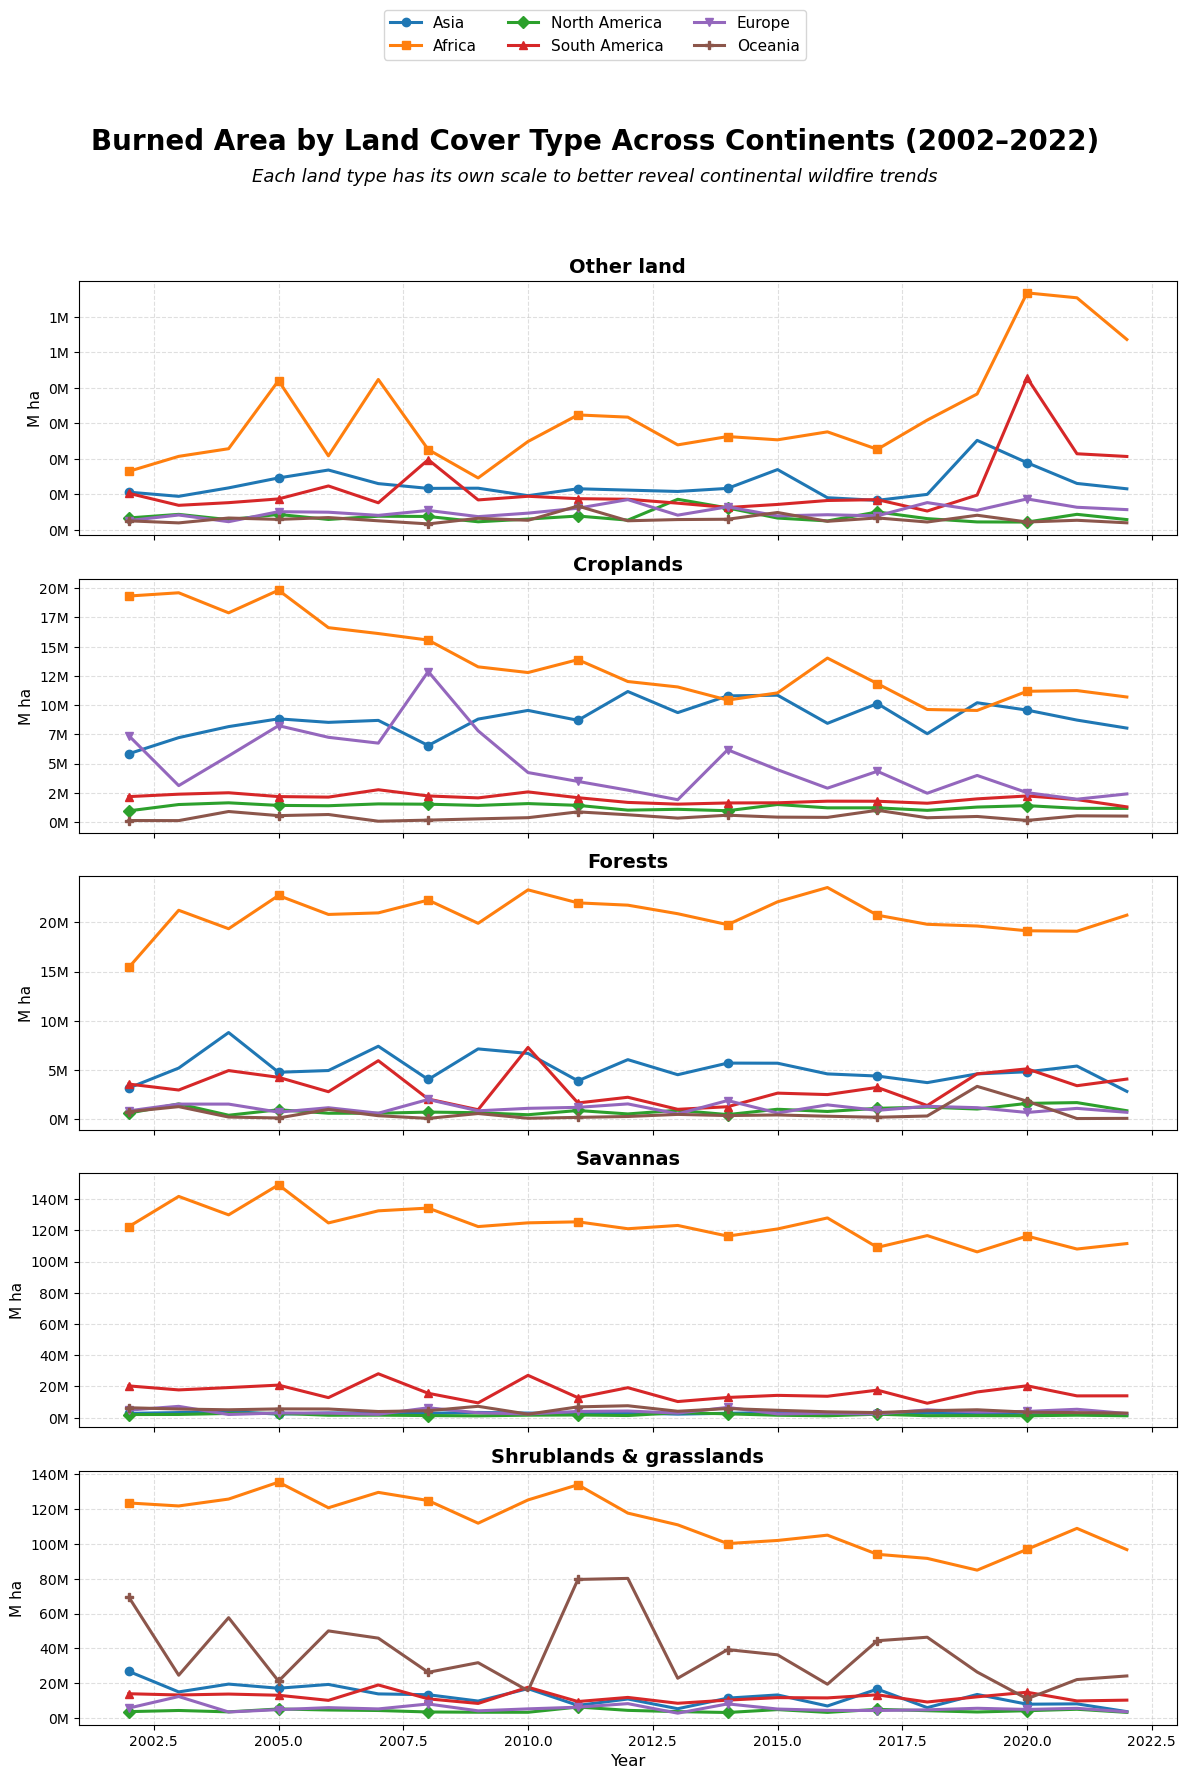

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# === Load dataset ===
file_path = r"C:\Users\jincy\OneDrive\Desktop\TealProject\Datasets\annual-burned-area-by-landcover\annual-burned-area-by-landcover.csv"
df = pd.read_csv(file_path)

# === Keep only needed continents ===
continents = ["Asia", "Africa", "North America", "South America", "Europe", "Oceania"]
df = df[df["Entity"].isin(continents)].copy()

# === Rename for readability ===
df.rename(columns={
    "Yearly burned area across other land categories": "Other land",
    "Yearly burned area across croplands": "Croplands",
    "Yearly burned area across forests": "Forests",
    "Yearly burned area across savannas": "Savannas",
    "Yearly burned area across shrublands and grasslands": "Shrublands & grasslands"
}, inplace=True)

# === Convert to Million hectares (M ha) ===
cover_types = ["Other land", "Croplands", "Forests", "Savannas", "Shrublands & grasslands"]
df[cover_types] = df[cover_types] / 1e6

# === Colors for continents ===
colors = {
    "Asia": "#1f77b4",
    "Africa": "#ff7f0e",
    "North America": "#2ca02c",
    "South America": "#d62728",
    "Europe": "#9467bd",
    "Oceania": "#8c564b"
}
markers = ["o", "s", "D", "^", "v", "P"]

# === Create separate subplots with independent y-axes ===
fig, axes = plt.subplots(len(cover_types), 1, figsize=(12, 18), sharex=True)
if len(cover_types) == 1:
    axes = [axes]  # handle edge case when only 1 plot

for i, land_type in enumerate(cover_types):
    ax = axes[i]
    
    for (continent, color), marker in zip(colors.items(), markers):
        sub = df[df["Entity"] == continent]
        ax.plot(sub["Year"], sub[land_type], 
                label=continent, color=color, 
                linewidth=2.2, marker=marker, markersize=6, markevery=3)
    
    ax.set_title(land_type, fontsize=14, weight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}M"))
    ax.set_ylabel("M ha", fontsize=11)

# Common x-axis label
axes[-1].set_xlabel("Year", fontsize=12)

# Main title
fig.suptitle("Burned Area by Land Cover Type Across Continents (2002–2022)", 
             fontsize=20, weight="bold", y=0.92)
fig.text(0.5, 0.89, "Each land type has its own scale to better reveal continental wildfire trends",
         ha="center", fontsize=13, style="italic")

# Shared legend on top
fig.legend(colors.keys(), loc="upper center", ncol=3, fontsize=11, bbox_to_anchor=(0.5, 0.99))

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()


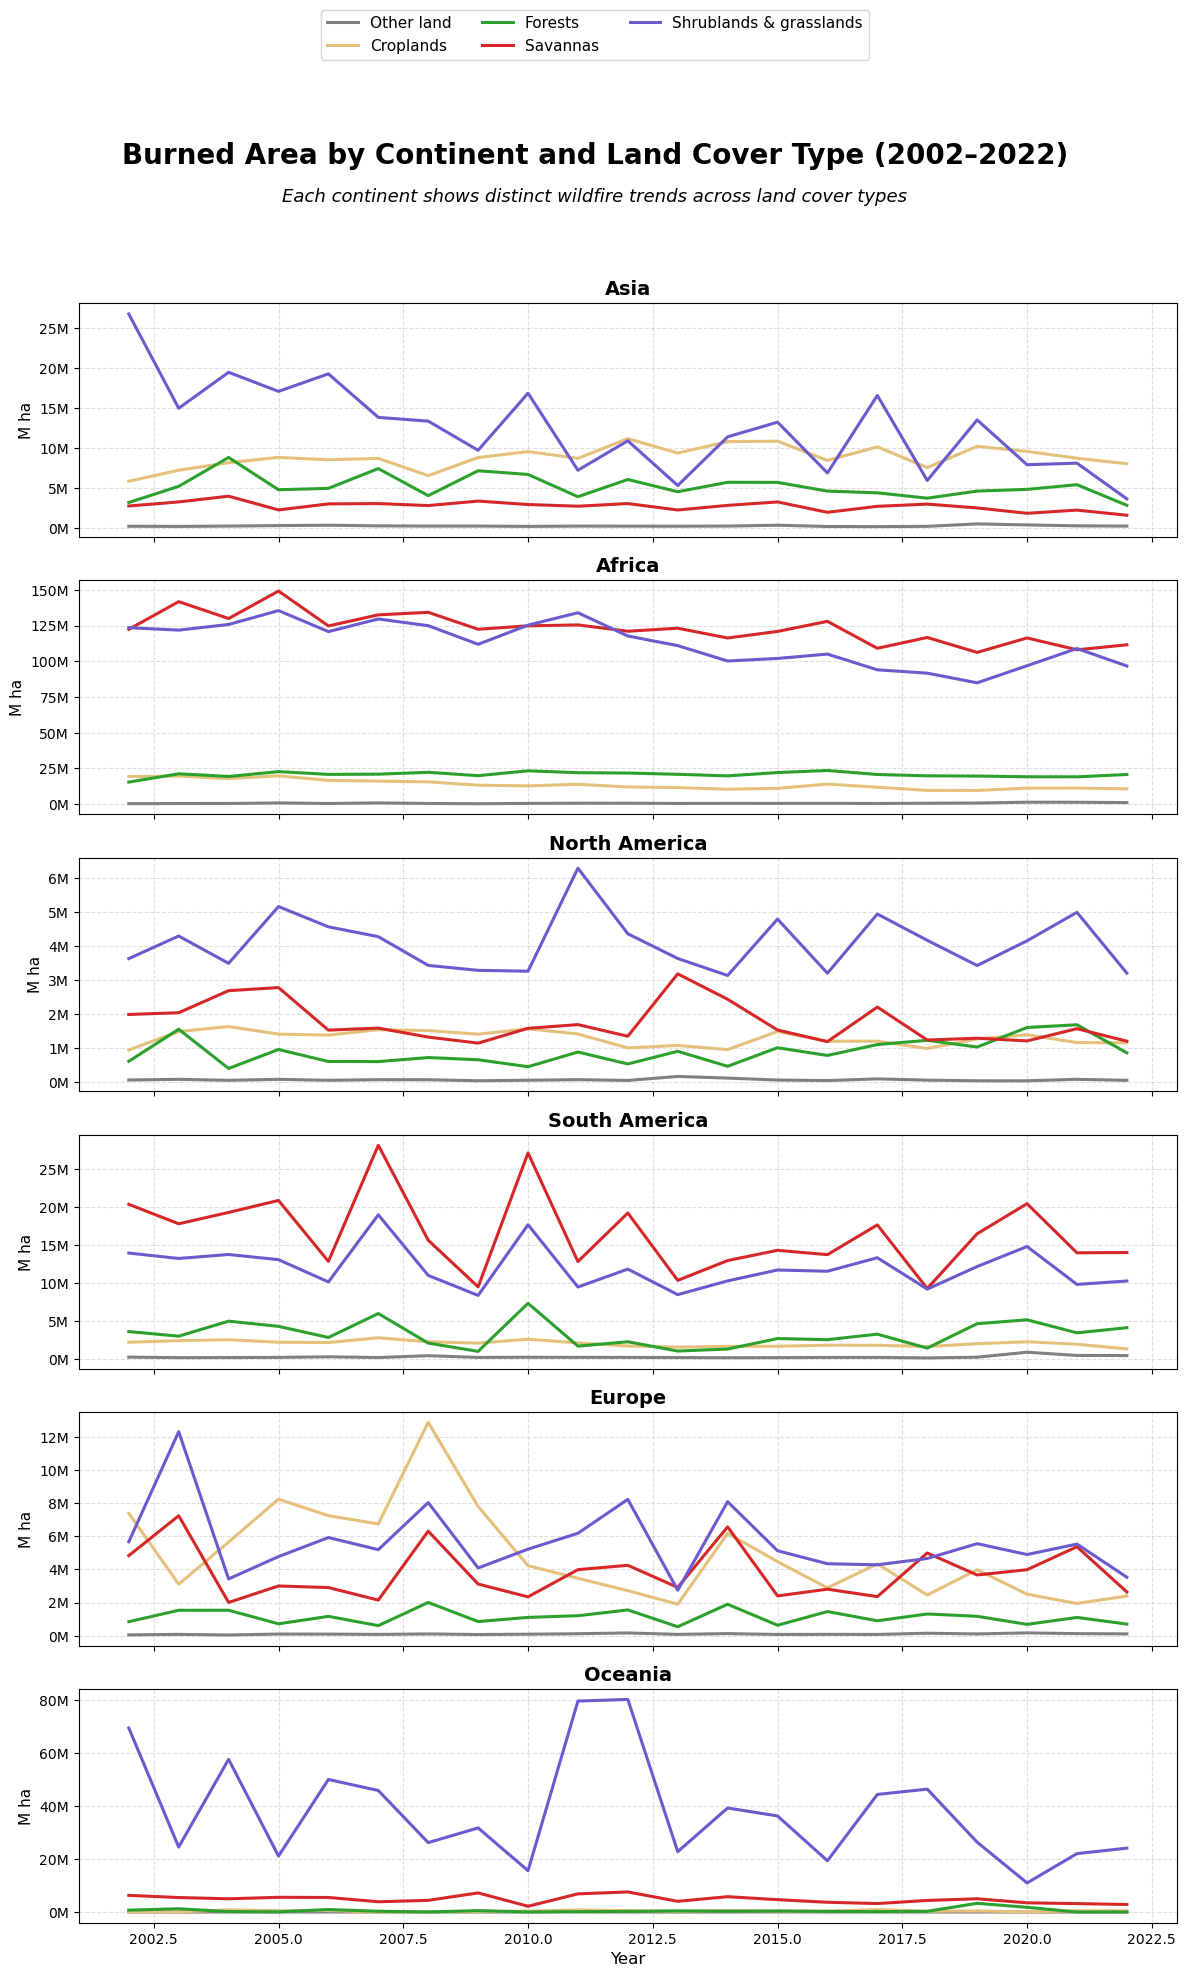

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# === Load dataset ===
file_path = r"C:\Users\jincy\OneDrive\Desktop\TealProject\Datasets\annual-burned-area-by-landcover\annual-burned-area-by-landcover.csv"
df = pd.read_csv(file_path)

# === Keep only needed continents ===
continents = ["Asia", "Africa", "North America", "South America", "Europe", "Oceania"]
df = df[df["Entity"].isin(continents)].copy()

# === Rename for readability ===
df.rename(columns={
    "Yearly burned area across other land categories": "Other land",
    "Yearly burned area across croplands": "Croplands",
    "Yearly burned area across forests": "Forests",
    "Yearly burned area across savannas": "Savannas",
    "Yearly burned area across shrublands and grasslands": "Shrublands & grasslands"
}, inplace=True)

# === Convert to Million hectares (M ha) ===
cover_types = ["Other land", "Croplands", "Forests", "Savannas", "Shrublands & grasslands"]
df[cover_types] = df[cover_types] / 1e6

# === Colors for land cover types ===
colors = {
    "Other land": "#7f7f7f",
    "Croplands": "#e5c07b",
    "Forests": "#2ca02c",
    "Savannas": "#d62728",
    "Shrublands & grasslands": "#6a5acd"
}

# === Create separate subplots with independent y-axes ===
fig, axes = plt.subplots(len(continents), 1, figsize=(12, 20), sharex=True)
if len(continents) == 1:
    axes = [axes]  # handle edge case if only 1 plot

for i, continent in enumerate(continents):
    ax = axes[i]
    sub = df[df["Entity"] == continent]
    
    for land_type, color in colors.items():
        ax.plot(sub["Year"], sub[land_type],
                label=land_type, color=color,
                linewidth=2.2)
    
    ax.set_title(continent, fontsize=14, weight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}M"))
    ax.set_ylabel("M ha", fontsize=11)

# Common x-axis label
axes[-1].set_xlabel("Year", fontsize=12)

# Main title
fig.suptitle("Burned Area by Continent and Land Cover Type (2002–2022)", 
             fontsize=20, weight="bold", y=0.92)
fig.text(0.5, 0.89, "Each continent shows distinct wildfire trends across land cover types",
         ha="center", fontsize=13, style="italic")

# Shared legend on top
fig.legend(colors.keys(), loc="upper center", ncol=3, fontsize=11, bbox_to_anchor=(0.5, 0.99))

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()


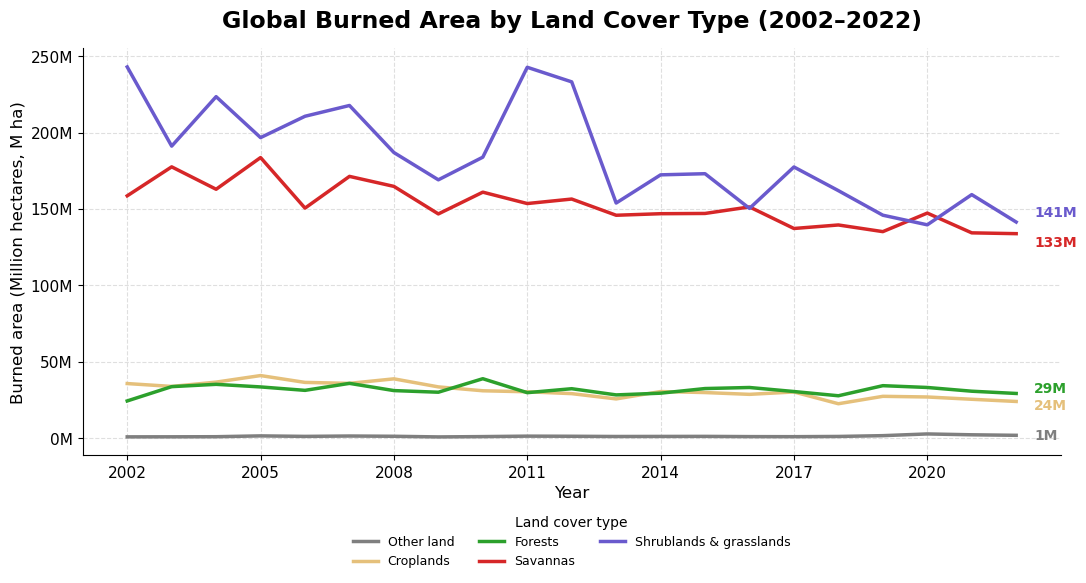

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# === Load dataset ===
file_path = r"C:\Users\jincy\OneDrive\Desktop\TealProject\Datasets\annual-burned-area-by-landcover\annual-burned-area-by-landcover.csv"
df = pd.read_csv(file_path)

# === Keep only World, years 2002–2022 ===
df = df[(df["Entity"] == "World") & (df["Year"].between(2002, 2022))].copy()

# === Rename columns ===
df.rename(columns={
    "Yearly burned area across other land categories": "Other land",
    "Yearly burned area across croplands": "Croplands",
    "Yearly burned area across forests": "Forests",
    "Yearly burned area across savannas": "Savannas",
    "Yearly burned area across shrublands and grasslands": "Shrublands & grasslands"
}, inplace=True)

# === Convert to Million hectares (M ha) ===
cover_types = ["Other land", "Croplands", "Forests", "Savannas", "Shrublands & grasslands"]
df[cover_types] = df[cover_types] / 1e6

# === Colors ===
colors = {
    "Other land": "#7f7f7f",
    "Croplands": "#e5c07b",
    "Forests": "#2ca02c",
    "Savannas": "#d62728",
    "Shrublands & grasslands": "#6a5acd"
}

# === Plot ===
plt.figure(figsize=(11, 6))  # more compact

for land_type, color in colors.items():
    plt.plot(df["Year"], df[land_type], 
             label=land_type, color=color, linewidth=2.5)

    # Annotate 2022 values with offsets
for land_type, color in colors.items():
    last_val = df.loc[df["Year"] == 2022, land_type].values[0]
    
    # Y-offsets to avoid overlap
    if land_type == "Shrublands & grasslands":
        offset = 6
    elif land_type == "Savannas":
        offset = -6
    elif land_type == "Forests":
        offset = 3
    elif land_type == "Croplands":
        offset = -3
    else:
        offset = 0
    
    plt.text(2022 + 0.4, last_val + offset, f"{int(last_val):,}M",
             color=color, fontsize=10, weight="bold", va="center")

# Titles
plt.title("Global Burned Area by Land Cover Type (2002–2022)", 
          fontsize=17, weight="bold", pad=15)


# Labels
plt.xlabel("Year", fontsize=12)
plt.ylabel("Burned area (Million hectares, M ha)", fontsize=12)

# Format y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}M'))

# Show fewer x-ticks (every 3 years)
plt.xticks(range(2002, 2023, 3), fontsize=11)
plt.yticks(fontsize=11)

# Style tweaks
plt.grid(True, linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Legend below the chart, blog-style
plt.legend(title="Land cover type", loc="upper center", 
           bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9, frameon=False)

plt.tight_layout()
plt.show()


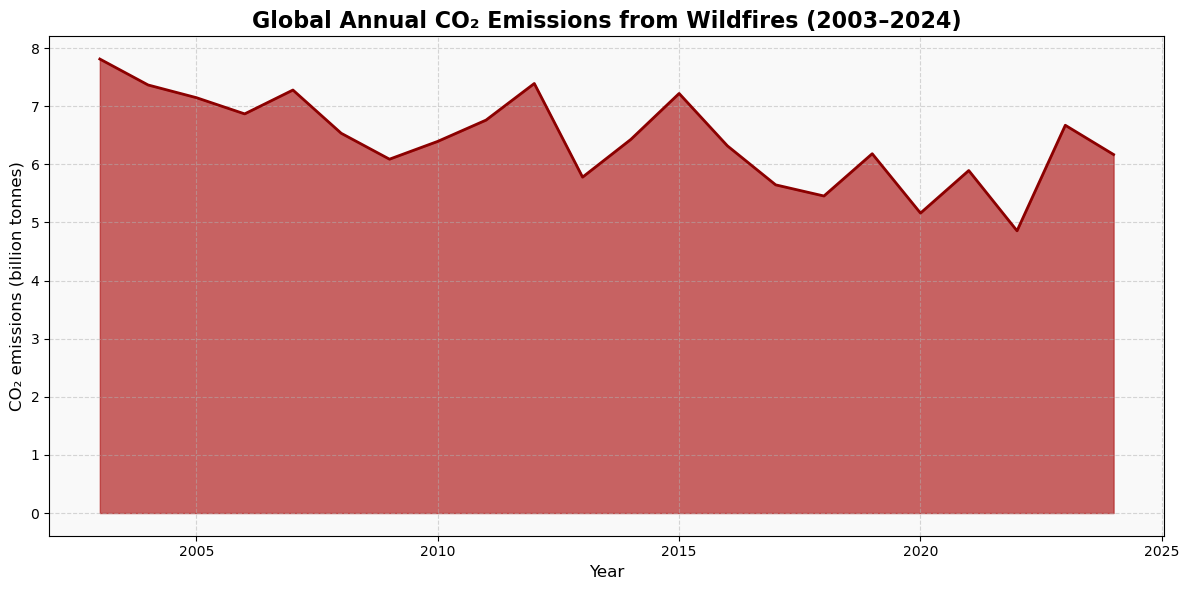

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load dataset ===
file_path = r"C:\Users\jincy\OneDrive\Desktop\TealProject\Datasets\annual-carbon-dioxide-emissions\annual-carbon-dioxide-emissions.csv"
df = pd.read_csv(file_path)

# === Filter only World and years <= 2024 ===
world = df[(df["Entity"] == "World") & (df["Year"] <= 2024)].copy()

# === Convert to billions of tonnes (Gt CO₂) ===
world["CO2_Gt"] = world["Annual carbon dioxide emissions"] / 1e9

# === Area chart ===
plt.figure(figsize=(12, 6))
plt.fill_between(world["Year"], world["CO2_Gt"], color="firebrick", alpha=0.7)
plt.plot(world["Year"], world["CO2_Gt"], color="darkred", linewidth=2)

# Title & subtitle
plt.title("Global Annual CO₂ Emissions from Wildfires (2003–2024)", fontsize=16, weight="bold")

# Labels
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO₂ emissions (billion tonnes)", fontsize=12)

# Style
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()
